In [42]:
# Importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.base import clone

# Chemins

DATA_PATH = "../data/processed"
MODEL_PATH = "../models"
REPORTS_PATH = "../reports/ml"
FIGURES_PATH = "../reports/figures/ml"

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

# Chargement des données

df = pd.read_csv(
    f"{DATA_PATH}/dataset_final.csv"
)

ml_data = pd.read_csv(
    f"{DATA_PATH}/dataset_model_ml.csv"
)

best_model = joblib.load(
    f"{MODEL_PATH}/best_model.pkl"
)

# Conversion des dates

df["date_vente"] = pd.to_datetime(
    df["date_vente"]
)

df["date_mois"] = pd.to_datetime(
    df["date_mois"]
)

ml_data["date_mois"] = pd.to_datetime(
    ml_data["date_mois"]
)

# Variables Open Data originales

external_features = [
    "inflation",
    "gdp_growth",
    "temperature",
    "precipitation",
    "interest_rate",
    "wheat_price",
    "corn_price",
    "soybean_price"
]

# Variables Open Data décalées d'un mois

external_lag_features = [
    "inflation_M1",
    "gdp_growth_M1",
    "temperature_M1",
    "precipitation_M1",
    "interest_rate_M1",
    "wheat_price_M1",
    "corn_price_M1",
    "soybean_price_M1"
]

# Variables numériques utilisées par le modèle

numeric_features = [
    "annee",
    "inflation_M1",
    "gdp_growth_M1",
    "temperature_M1",
    "precipitation_M1",
    "interest_rate_M1",
    "wheat_price_M1",
    "corn_price_M1",
    "soybean_price_M1",
    "vente_M1",
    "vente_M2",
    "vente_M12",
    "moyenne_mobile_3"
]

# Variables catégorielles

categorical_features = [
    "mois",
    "categorie_produit_2",
    "produit",
    "code_pays"
]

features = (
    numeric_features
    + categorical_features
)

target = "quantite_vendue"

# Réentraînement sur toutes les données disponibles

production_model = clone(
    best_model
)

production_model.fit(
    ml_data[features],
    ml_data[target]
)

# Sauvegarde du modèle de production

joblib.dump(
    production_model,
    f"{MODEL_PATH}/best_model_production.pkl"
)

print("Modèle de production entraîné")
print("Dimensions du dataset ML :", ml_data.shape)
print("Dernier mois disponible :", df["date_mois"].max())
print("Variables utilisées :", features)

Modèle de production entraîné
Dimensions du dataset ML : (2157, 33)
Dernier mois disponible : 2016-12-01 00:00:00
Variables utilisées : ['annee', 'inflation_M1', 'gdp_growth_M1', 'temperature_M1', 'precipitation_M1', 'interest_rate_M1', 'wheat_price_M1', 'corn_price_M1', 'soybean_price_M1', 'vente_M1', 'vente_M2', 'vente_M12', 'moyenne_mobile_3', 'mois', 'categorie_produit_2', 'produit', 'code_pays']


In [43]:
# Dernières valeurs Open Data disponibles

external_latest = (
    df
    .sort_values("date_mois")
    .drop_duplicates(
        subset=["code_pays"],
        keep="last"
    )
    [
        ["code_pays"] + external_features
    ]
)

# Les dernières valeurs connues correspondent
# aux variables du mois précédent

external_latest = external_latest.rename(
    columns={
        "inflation": "inflation_M1",
        "gdp_growth": "gdp_growth_M1",
        "temperature": "temperature_M1",
        "precipitation": "precipitation_M1",
        "interest_rate": "interest_rate_M1",
        "wheat_price": "wheat_price_M1",
        "corn_price": "corn_price_M1",
        "soybean_price": "soybean_price_M1"
    }
)

print(
    "Variables Open Data disponibles :",
    external_latest.columns.tolist()
)

Variables Open Data disponibles : ['code_pays', 'inflation_M1', 'gdp_growth_M1', 'temperature_M1', 'precipitation_M1', 'interest_rate_M1', 'wheat_price_M1', 'corn_price_M1', 'soybean_price_M1']


In [44]:
# Liste contenant les prévisions

liste_previsions = []

# Prévision mois par mois

for numero_mois in range(
    1,
    horizon_prevision + 1
):

    # Date du mois à prévoir

    date_future = (
        date_fin
        + pd.DateOffset(months=numero_mois)
    )

    # Calcul des variables de retard

    future_lags = (
        historique
        .sort_values(
            [
                "produit",
                "code_pays",
                "date_mois"
            ]
        )
        .groupby(
            [
                "produit",
                "code_pays"
            ],
            as_index=False
        )
        .agg(
            vente_M1=(
                "quantite_vendue",
                lambda x: x.iloc[-1]
            ),
            vente_M2=(
                "quantite_vendue",
                lambda x: x.iloc[-2]
            ),
            vente_M12=(
                "quantite_vendue",
                lambda x: x.iloc[-12]
            ),
            moyenne_mobile_3=(
                "quantite_vendue",
                lambda x: x.iloc[-3:].mean()
            )
        )
    )

    # Création du dataset du mois futur

    future_month = future_lags.merge(
        product_info,
        on=[
            "produit",
            "code_pays"
        ],
        how="left"
    )

    future_month = future_month.merge(
        external_latest,
        on="code_pays",
        how="left"
    )

    # Variables temporelles

    future_month["date_mois"] = date_future
    future_month["annee"] = date_future.year
    future_month["mois"] = date_future.month
    future_month["horizon_mois"] = numero_mois

    # Hypothèse concernant l'Open Data

    future_month["hypothese_open_data"] = (
    "Valeurs Open Data de décembre 2016 maintenues constantes"
    )

    # Prévision de la quantité vendue

    future_month["quantite_predite"] = (
        production_model.predict(
            future_month[features]
        )
    )

    # Une quantité prédite ne peut pas être négative

    future_month["quantite_predite"] = (
        future_month["quantite_predite"]
        .clip(lower=0)
    )

    # Ajout du mois dans la liste

    liste_previsions.append(
        future_month.copy()
    )

    # Les prévisions sont ajoutées à l'historique
    # Elles seront utilisées pour prévoir le mois suivant

    nouvelles_ventes = future_month[
        [
            "date_mois",
            "produit",
            "code_pays",
            "quantite_predite"
        ]
    ].copy()

    nouvelles_ventes = nouvelles_ventes.rename(
        columns={
            "quantite_predite": "quantite_vendue"
        }
    )

    historique = pd.concat(
        [
            historique,
            nouvelles_ventes
        ],
        ignore_index=True
    )

# Regroupement de toutes les prévisions

predictions_future = pd.concat(
    liste_previsions,
    ignore_index=True
)

predictions_future = predictions_future.sort_values(
    [
        "date_mois",
        "produit",
        "code_pays"
    ]
).reset_index(drop=True)

print("Prévisions terminées")

print(
    "Période prévue :",
    predictions_future["date_mois"].min(),
    "au",
    predictions_future["date_mois"].max()
)

print(
    "Nombre de prévisions :",
    len(predictions_future)
)

predictions_future[
    [
        "date_mois",
        "horizon_mois",
        "produit",
        "code_pays",
        "vente_M1",
        "vente_M2",
        "vente_M12",
        "quantite_predite"
    ]
].head(10)

Prévisions terminées
Période prévue : 2017-01-01 00:00:00 au 2017-12-01 00:00:00
Nombre de prévisions : 288


,date_mois,horizon_mois,produit,code_pays,vente_M1,vente_M2,vente_M12,quantite_predite
0,2017-01-01,1,cattle feeder mixer (self propelled),CAN,3.100038,3.100038,5.042128,4.127108
1,2017-01-01,1,cattle feeder mixer (self propelled),USA,4.924271,4.924271,4.591660,5.518859
2,2017-01-01,1,combine harvester (cereals) & cotton picker,USA,797.366330,804.528672,691.903736,807.700918
3,2017-01-01,1,forage harvester (self propelled),CAN,3.100038,3.100038,5.042128,4.127108
4,2017-01-01,1,forage harvester (self propelled),USA,4.924271,4.924271,4.591660,5.518859
5,2017-01-01,1,mower conditionner - grass harvesters (self pr...,USA,4.924271,4.924271,4.591660,5.518859
6,2017-01-01,1,non-straddle fruit harvester (self propelled) ...,USA,9.865468,10.315936,8.339070,9.863355
7,2017-01-01,1,other forestry equipment (knuckleboom loaders...,CAN,3.100038,3.100038,4.591660,4.127108
8,2017-01-01,1,"other tractor, trailers, vehicles",USA,4.924271,4.924271,4.591660,5.518859
9,2017-01-01,1,"others wine, fruit & vegetable",USA,4.924271,4.924271,4.591660,5.518859


In [45]:
# Nombre de séries produit-pays

nombre_series = (
    active_series[
        [
            "produit",
            "code_pays"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

# Nombre de lignes attendu

nombre_lignes_attendu = (
    nombre_series
    * horizon_prevision
)

# Nombre de valeurs manquantes

valeurs_manquantes = (
    predictions_future[
        features
        + ["quantite_predite"]
    ]
    .isna()
    .sum()
    .sum()
)

# Vérifications

assert len(predictions_future) == nombre_lignes_attendu

assert (
    predictions_future["date_mois"].nunique()
    == horizon_prevision
)

assert valeurs_manquantes == 0

assert (
    predictions_future["quantite_predite"].min()
    >= 0
)

print("Toutes les vérifications sont correctes")
print("Nombre de séries :", nombre_series)
print("Nombre de mois :", horizon_prevision)
print("Nombre de lignes attendu :", nombre_lignes_attendu)
print("Nombre de lignes obtenu :", len(predictions_future))
print("Valeurs manquantes :", valeurs_manquantes)

predictions_future.groupby(
    "date_mois"
).size()

Toutes les vérifications sont correctes
Nombre de séries : 24
Nombre de mois : 12
Nombre de lignes attendu : 288
Nombre de lignes obtenu : 288
Valeurs manquantes : 0


date_mois
2017-01-01    24
2017-02-01    24
2017-03-01    24
2017-04-01    24
2017-05-01    24
2017-06-01    24
2017-07-01    24
2017-08-01    24
2017-09-01    24
2017-10-01    24
2017-11-01    24
2017-12-01    24
dtype: int64

In [46]:
# Chargement des prédictions historiques

predictions_test = pd.read_csv(
    f"{REPORTS_PATH}/predictions_test.csv"
)

# Calcul de l'erreur historique

predictions_test["erreur"] = (
    predictions_test["quantite_reelle"]
    - predictions_test["quantite_predite"]
)

# Erreur par produit et pays

erreur_produit = (
    predictions_test
    .groupby(
        [
            "produit",
            "code_pays"
        ],
        as_index=False
    )
    .agg(
        ecart_type_erreur=("erreur", "std"),
        nombre_observations=("erreur", "count")
    )
)

# Erreur globale du modèle

erreur_globale = (
    predictions_test["erreur"].std()
)

# Utilisation de l'erreur globale
# pour les séries ayant moins de trois observations

erreur_produit.loc[
    erreur_produit["nombre_observations"] < 3,
    "ecart_type_erreur"
] = erreur_globale

erreur_produit["ecart_type_erreur"] = (
    erreur_produit["ecart_type_erreur"]
    .fillna(erreur_globale)
)

# Nouveau DataFrame contenant les stocks

predictions_stock = predictions_future.merge(
    erreur_produit[
        [
            "produit",
            "code_pays",
            "ecart_type_erreur"
        ]
    ],
    on=[
        "produit",
        "code_pays"
    ],
    how="left"
)

predictions_stock["ecart_type_erreur"] = (
    predictions_stock["ecart_type_erreur"]
    .fillna(erreur_globale)
)

# Niveau de service proche de 95 %

coefficient_service = 1.65

# Délai d'approvisionnement supposé égal à un mois

delai_approvisionnement = 1

# Marge d'incertitude et stock de sécurité

predictions_stock["stock_securite"] = np.ceil(
    coefficient_service
    * predictions_stock["ecart_type_erreur"]
    * np.sqrt(delai_approvisionnement)
).astype(int)

predictions_stock["stock_securite"] = (
    predictions_stock["stock_securite"]
    .clip(lower=0)
)

# Intervalle indicatif de prévision

predictions_stock["borne_inferieure"] = (
    predictions_stock["quantite_predite"]
    - predictions_stock["stock_securite"]
).clip(lower=0)

predictions_stock["borne_superieure"] = (
    predictions_stock["quantite_predite"]
    + predictions_stock["stock_securite"]
)

# Point de commande

predictions_stock["point_commande"] = np.ceil(
    predictions_stock["quantite_predite"]
    * delai_approvisionnement
    + predictions_stock["stock_securite"]
).astype(int)

# Stock cible recommandé

predictions_stock["stock_cible_recommande"] = np.ceil(
    predictions_stock["quantite_predite"]
    + predictions_stock["stock_securite"]
).astype(int)

# Informations sur les hypothèses

predictions_stock["niveau_service"] = 95

predictions_stock["delai_approvisionnement_mois"] = (
    delai_approvisionnement
)

# Arrondi des valeurs décimales

predictions_stock["quantite_predite"] = (
    predictions_stock["quantite_predite"]
    .round(2)
)

predictions_stock["borne_inferieure"] = (
    predictions_stock["borne_inferieure"]
    .round(2)
)

predictions_stock["borne_superieure"] = (
    predictions_stock["borne_superieure"]
    .round(2)
)

predictions_stock["ecart_type_erreur"] = (
    predictions_stock["ecart_type_erreur"]
    .round(2)
)

print("Recommandations de stock calculées")
print("Nombre de lignes :", len(predictions_stock))

predictions_stock[
    [
        "date_mois",
        "produit",
        "code_pays",
        "quantite_predite",
        "borne_inferieure",
        "borne_superieure",
        "stock_securite",
        "stock_cible_recommande"
    ]
].head(10)

Recommandations de stock calculées
Nombre de lignes : 288


,date_mois,produit,code_pays,quantite_predite,borne_inferieure,borne_superieure,stock_securite,stock_cible_recommande
0,2017-01-01,cattle feeder mixer (self propelled),CAN,4.13,0.00,19.13,15,20
1,2017-01-01,cattle feeder mixer (self propelled),USA,5.52,0.52,10.52,5,11
2,2017-01-01,combine harvester (cereals) & cotton picker,USA,807.70,231.70,1383.70,576,1384
3,2017-01-01,forage harvester (self propelled),CAN,4.13,0.00,11.13,7,12
4,2017-01-01,forage harvester (self propelled),USA,5.52,0.52,10.52,5,11
5,2017-01-01,mower conditionner - grass harvesters (self pr...,USA,5.52,0.00,11.52,6,12
6,2017-01-01,non-straddle fruit harvester (self propelled) ...,USA,9.86,0.00,138.86,129,139
7,2017-01-01,other forestry equipment (knuckleboom loaders...,CAN,4.13,2.13,6.13,2,7
8,2017-01-01,"other tractor, trailers, vehicles",USA,5.52,0.00,11.52,6,12
9,2017-01-01,"others wine, fruit & vegetable",USA,5.52,0.00,19.52,14,20


In [47]:
# Sélection des colonnes finales

resultats_stock = predictions_stock[
    [
        "date_mois",
        "horizon_mois",
        "produit",
        "categorie_produit_1",
        "categorie_produit_2",
        "region",
        "pays",
        "code_pays",
        "quantite_predite",
        "borne_inferieure",
        "borne_superieure",
        "ecart_type_erreur",
        "stock_securite",
        "point_commande",
        "stock_cible_recommande",
        "niveau_service",
        "delai_approvisionnement_mois",
        "hypothese_open_data"
    ]
].copy()

# Enregistrement des prévisions détaillées

resultats_stock.to_csv(
    f"{REPORTS_PATH}/previsions_stock_futur.csv",
    index=False
)

# Résumé mensuel

resume_mensuel = (
    resultats_stock
    .groupby(
        "date_mois",
        as_index=False
    )
    .agg(
        demande_predite=("quantite_predite", "sum"),
        stock_securite=("stock_securite", "sum"),
        stock_recommande=("stock_cible_recommande", "sum"),
        nombre_series=("produit", "count")
    )
)

resume_mensuel[
    [
        "demande_predite",
        "stock_securite",
        "stock_recommande"
    ]
] = resume_mensuel[
    [
        "demande_predite",
        "stock_securite",
        "stock_recommande"
    ]
].round(2)

resume_mensuel.to_csv(
    f"{REPORTS_PATH}/resume_previsions_mensuelles.csv",
    index=False
)

print("Fichiers enregistrés avec succès")

print(
    "Période prévue :",
    resultats_stock["date_mois"].min(),
    "au",
    resultats_stock["date_mois"].max()
)

print("Nombre de lignes :", len(resultats_stock))
print("Nombre de produits :", resultats_stock["produit"].nunique())
print("Nombre de pays :", resultats_stock["code_pays"].nunique())

resume_mensuel

Fichiers enregistrés avec succès
Période prévue : 2017-01-01 00:00:00 au 2017-12-01 00:00:00
Nombre de lignes : 288
Nombre de produits : 20
Nombre de pays : 2


,date_mois,demande_predite,stock_securite,stock_recommande,nombre_series
0,2017-01-01,948.47,1239,2200,24
1,2017-02-01,941.28,1239,2187,24
2,2017-03-01,1041.22,1239,2287,24
3,2017-04-01,941.28,1239,2187,24
4,2017-05-01,1100.34,1239,2346,24
5,2017-06-01,941.28,1239,2187,24
6,2017-07-01,965.99,1239,2212,24
7,2017-08-01,941.28,1239,2187,24
8,2017-09-01,929.13,1239,2175,24
9,2017-10-01,933.21,1239,2179,24


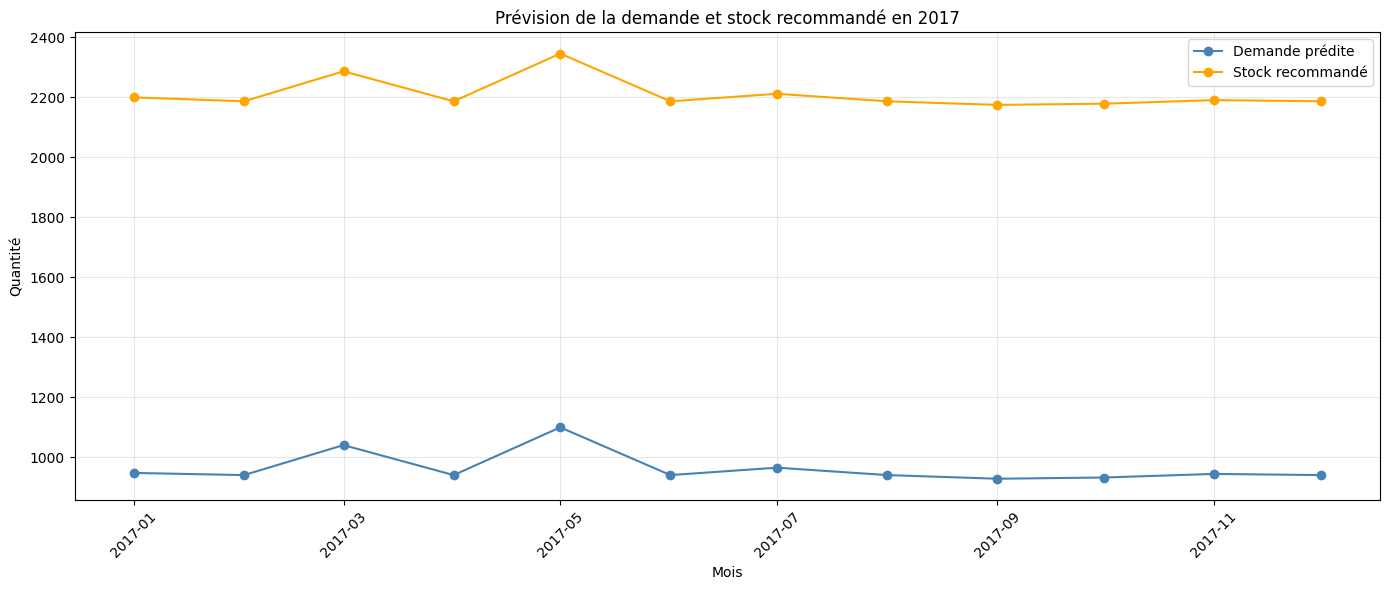

In [48]:
# Évolution mensuelle de la demande et du stock recommandé

plt.figure(figsize=(14, 6))

plt.plot(
    resume_mensuel["date_mois"],
    resume_mensuel["demande_predite"],
    marker="o",
    label="Demande prédite",
    color="steelblue"
)

plt.plot(
    resume_mensuel["date_mois"],
    resume_mensuel["stock_recommande"],
    marker="o",
    label="Stock recommandé",
    color="orange"
)

plt.title(
    "Prévision de la demande et stock recommandé en 2017"
)

plt.xlabel("Mois")
plt.ylabel("Quantité")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/previsions_stock_2017.png"
)

plt.show()
plt.close()

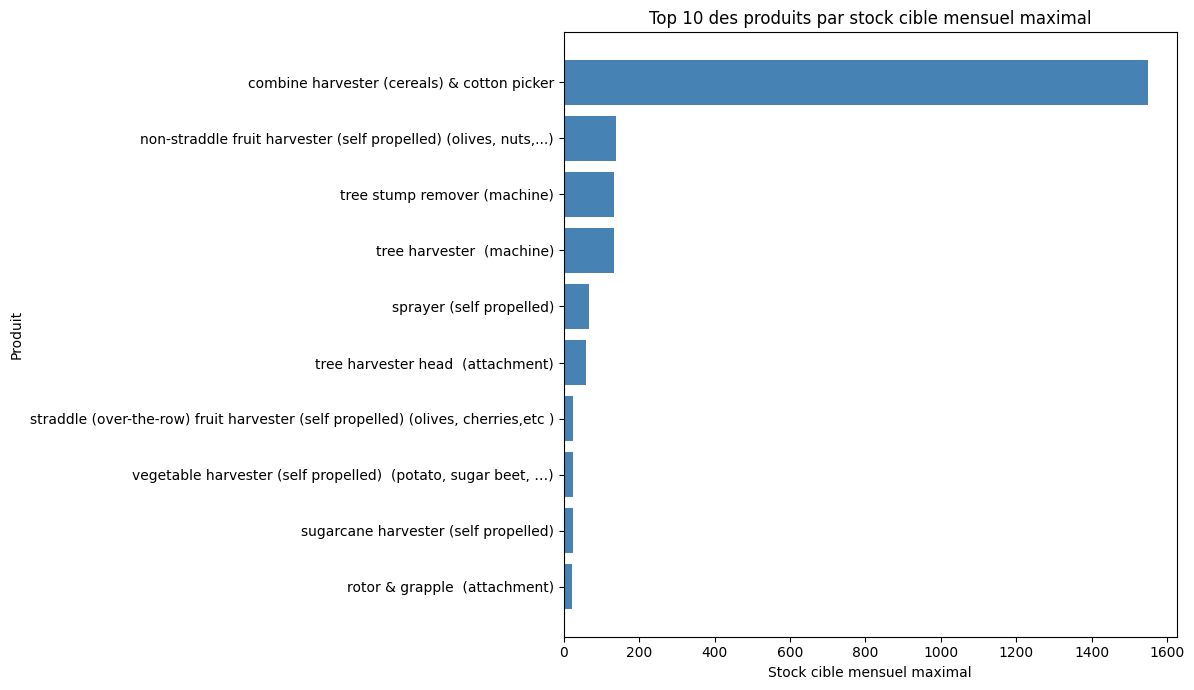

../models/best_model_production.pkl True
../reports/ml/previsions_stock_futur.csv True
../reports/ml/resume_previsions_mensuelles.csv True
../reports/ml/top_stock_futur.csv True
../reports/figures/ml/previsions_stock_2017.png True
../reports/figures/ml/top_stock_futur.png True


,produit,demande_annuelle_predite,stock_securite_max,stock_cible_moyen,stock_cible_max
1,combine harvester (cereals) & cotton picker,10014.13,576,1410.92,1548
4,non-straddle fruit harvester (self propelled) ...,118.32,129,139.00,139
17,tree stump remover (machine),42.08,129,133.08,134
15,tree harvester (machine),100.84,129,70.58,134
9,sprayer (self propelled),141.84,56,68.00,68
16,tree harvester head (attachment),160.40,48,44.54,58
12,straddle (over-the-row) fruit harvester (self ...,58.76,20,25.08,26
19,"vegetable harvester (self propelled) (potato,...",118.26,15,25.00,25
13,sugarcane harvester (self propelled),118.14,15,25.00,25
8,rotor & grapple (attachment),58.76,15,20.08,21


In [49]:
# Résumé annuel par produit

top_stock = (
    resultats_stock
    .groupby(
        "produit",
        as_index=False
    )
    .agg(
        demande_annuelle_predite=(
            "quantite_predite",
            "sum"
        ),
        stock_securite_max=(
            "stock_securite",
            "max"
        ),
        stock_cible_moyen=(
            "stock_cible_recommande",
            "mean"
        ),
        stock_cible_max=(
            "stock_cible_recommande",
            "max"
        )
    )
    .sort_values(
        "stock_cible_max",
        ascending=False
    )
    .head(10)
)

# Arrondi

top_stock[
    [
        "demande_annuelle_predite",
        "stock_cible_moyen"
    ]
] = top_stock[
    [
        "demande_annuelle_predite",
        "stock_cible_moyen"
    ]
].round(2)

# Enregistrement

top_stock.to_csv(
    f"{REPORTS_PATH}/top_stock_futur.csv",
    index=False
)

# Graphique

plt.figure(figsize=(12, 7))

plt.barh(
    top_stock["produit"],
    top_stock["stock_cible_max"],
    color="steelblue"
)

plt.title(
    "Top 10 des produits par stock cible mensuel maximal"
)

plt.xlabel("Stock cible mensuel maximal")
plt.ylabel("Produit")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/top_stock_futur.png"
)

plt.show()
plt.close()

# Vérification des fichiers

fichiers_crees = [
    f"{MODEL_PATH}/best_model_production.pkl",
    f"{REPORTS_PATH}/previsions_stock_futur.csv",
    f"{REPORTS_PATH}/resume_previsions_mensuelles.csv",
    f"{REPORTS_PATH}/top_stock_futur.csv",
    f"{FIGURES_PATH}/previsions_stock_2017.png",
    f"{FIGURES_PATH}/top_stock_futur.png"
]

for fichier in fichiers_crees:
    print(fichier, os.path.exists(fichier))

top_stock